# Tutorial: Solving Rule-Compliant Trajectory Repairing Problems
This tutorial demonstrates how we can use the existing trajectory repairing framework to solve real planning problems that the initially-planned trajectory is not rule-compliant

## 0. Preparation
Before you proceed with this tutorial, make sure that

* you have gone through the tutorials on **CommonRoad Input-Output**
* you have installed all necessary modules for **CommonRoad Repairer** according to the installation manual.

Let's start with importing relevant modules and classes for setting up the CommonRoad (CR) scenario.

In [31]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
from IPython.display import clear_output
path_notebook = os.getcwd()

# CommonRoad packages
from commonroad.common.file_reader import CommonRoadFileReader

from commonroad_repair.crrepairer.abstraction.abstracter import RuleAbstracter
from commonroad_repair.crrepairer.t_solver.t_solver import TSolver
from commonroad_repair.crrepairer.t_solver.qp_planner import QPPlannerRepair
from commonroad_repair.crrepairer.t_solver.utils import convert_traj_to_ego_vehicle
from commonroad_repair.crrepairer.repairer.smt_repairer import SMTTrajectoryRepairer

# add the root folder to python path
# sys.path.append(os.path.join(path_notebook, "../../"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Loading CR Scenario and Planning Problem Set
In the next step, we load CommonRoad scenarios and their planning problems.

In [35]:
path_scenario = os.path.join(path_notebook, "../scenarios/")
id_scenario = 'DEU_Gar-1_1_T-1'

# read in scenario and planning problem set, lanelet_assignment needs to be True
scenario, planning_problem_set = CommonRoadFileReader(path_scenario + id_scenario + '.xml').open(lanelet_assignment=True)
# retrieve the first planning problem in the problem set
planning_problem = list(planning_problem_set.planning_problem_dict.values())[0]

## 2. Select the ego vehicle, whose initial trajectory violates traffic rules
We need to define the rule and the vehicle ID

In [36]:
ego_id = 200
rule = "R_G1"
# ego vehicle with the initially-planned trajectory
ego_initial = scenario.obstacle_by_id(ego_id)

## 3. Trajectory Repairing
### 3.1 Define the rule abstracter and initialize the trajectory repairing framework
We use the lazy SMT solver for our trajectory repairing problem. This method abstracts the input formula to a propositional one and feeds it to a SAT solver to suggest possible assignments. The T-solver checks the satisfiability of the obtained assignment in a theory T (T-consistency) to refine the formula and guide the SAT solver. Therefore, we need first to define the rule abstracter and then use it to initialize the trajectory repairing problem with the initially-planned trajectory.

In [37]:
rule_abstracter = RuleAbstracter(scenario,
                                 planning_problem,
                                 ego_id,
                                 rule)
repairer = SMTTrajectoryRepairer(rule_abstracter,
                                 ego_initial)

ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1
ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1
ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1
ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1
ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1
ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1
ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1
ANTLR runtime and generated code versions disagree: 4.7.2!=4.5.1


### 3.2 start repairing
1. find the cut-off state
2. use QP-planner to obtain the repaired trajectory

In [38]:
# call the repairing function
repaired_traj = repairer.repair()
# updated ego vehicle with the repaired trajectory
ego_vehicle = convert_traj_to_ego_vehicle(ego_initial.obstacle_shape,
                                          ego_initial.initial_state,
                                          repaired_traj)
# we use the existing CommonRoad vehicle models, thus, the vehicle dimension needs to be updated
ego_initial.prediction.shape = ego_vehicle.prediction.shape

INFO:Route Planner [DEU_Gar-1_1_T-1]:Route planner started


<SATSolver>: model is {'d'}
Category.LON_POS keeps_safe_distance_prec__a0_a1
<TSolver>: compliant maneuver [<CutOffAction.KICKDOWN: 'kick-down'>, <CutOffAction.BRAKE: 'brake'>] is selected
<T-solver>: tc = 1.3, tv = 1.4000000000000001
		 Longitudinal optimization
<QPRepairer/_rule_constraints>: we cannot add constraints for cut in
Problem is convex: True
		 Lateral optimization
Problem is convex: True


### 3.3 Visualize the result
1. initial configuration
2. repaired configuration

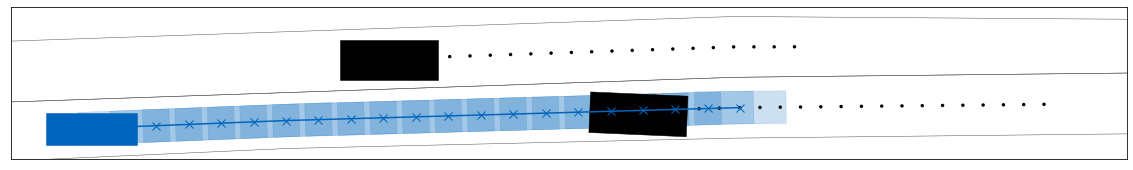

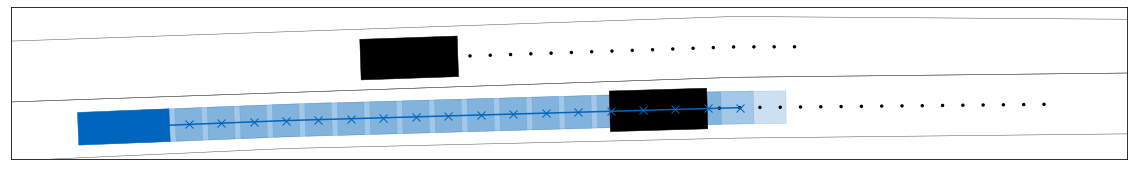

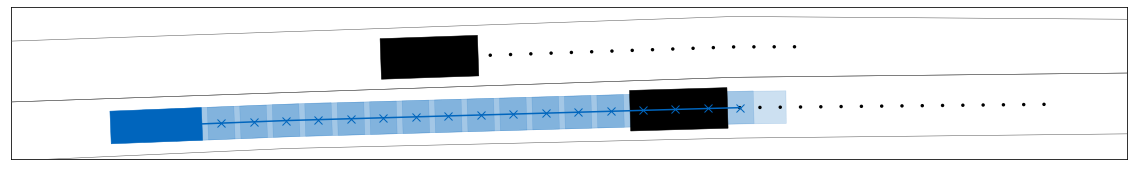

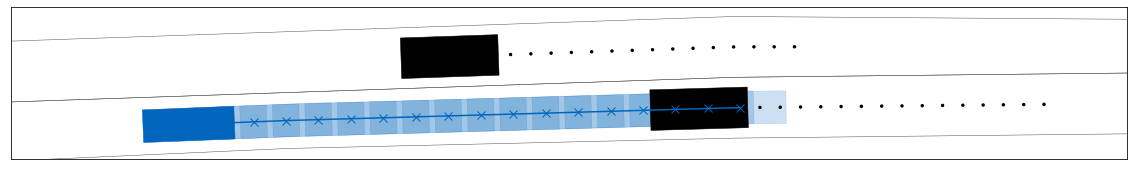

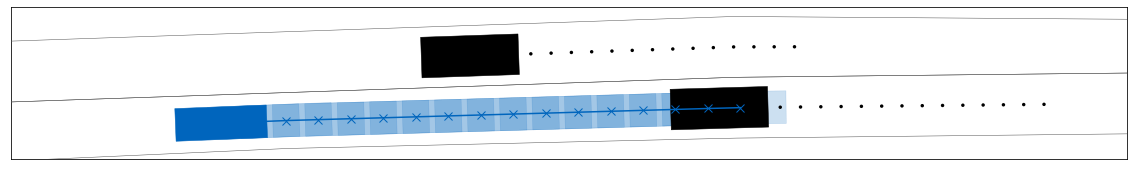

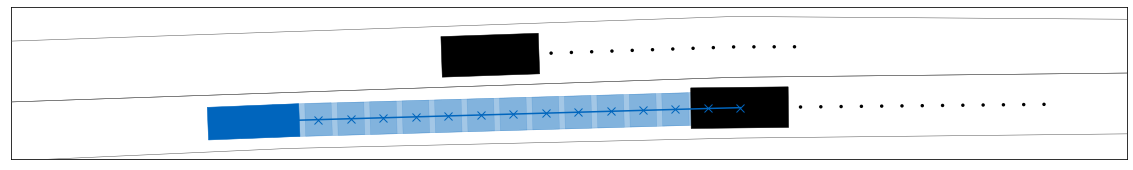

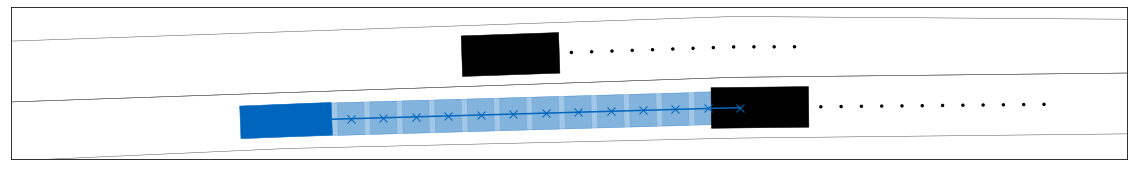

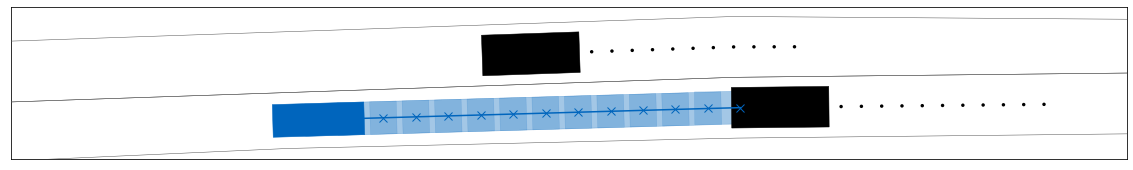

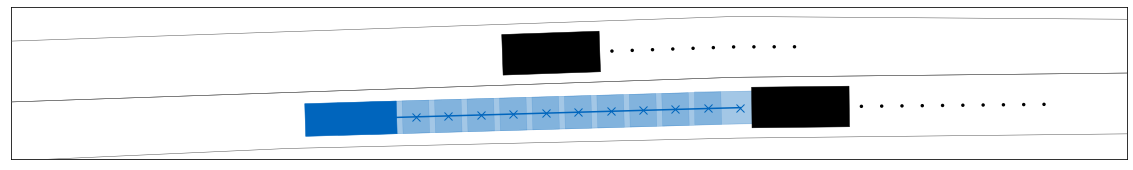

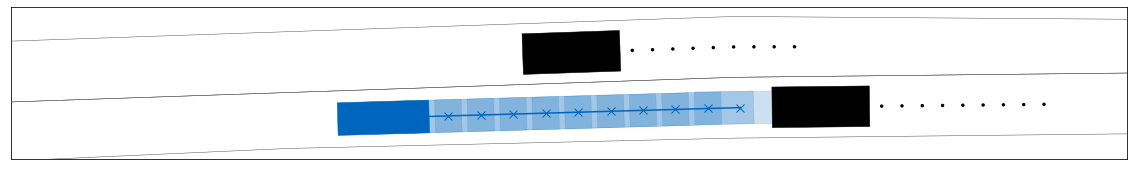

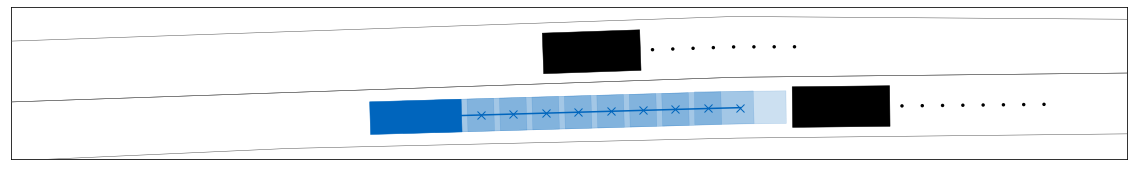

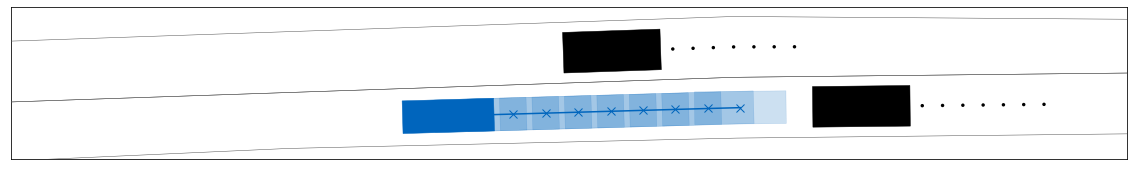

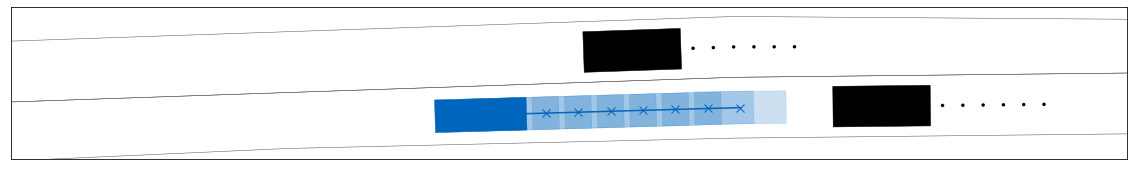

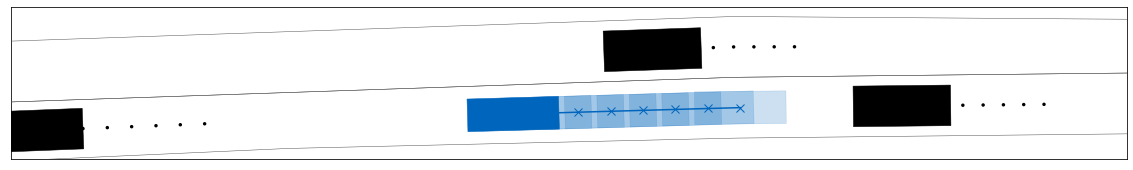

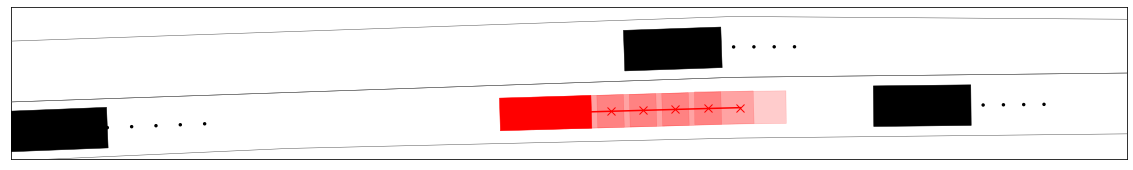

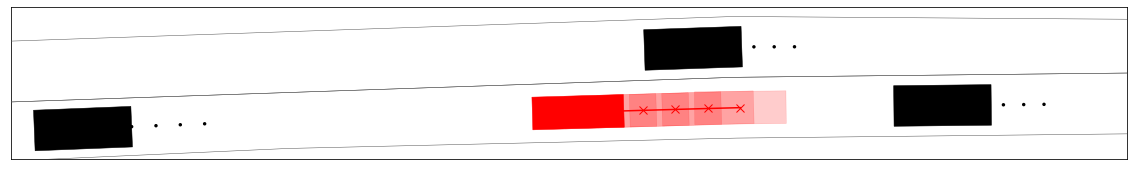

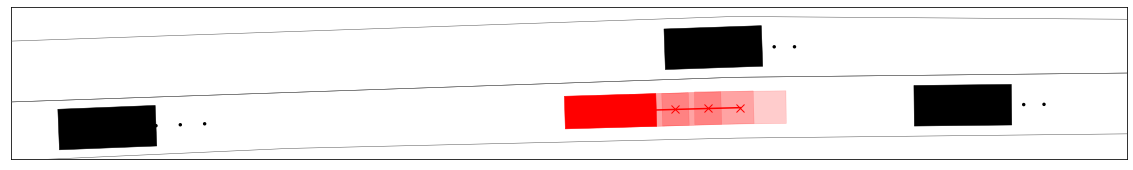

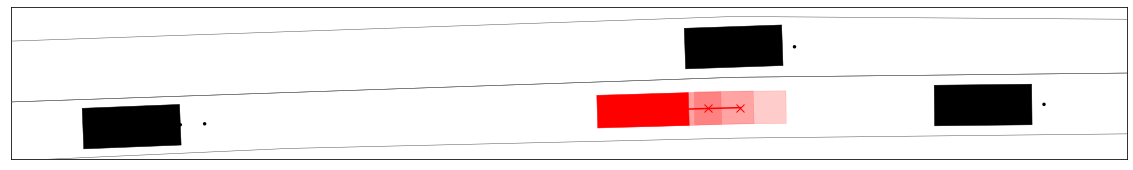

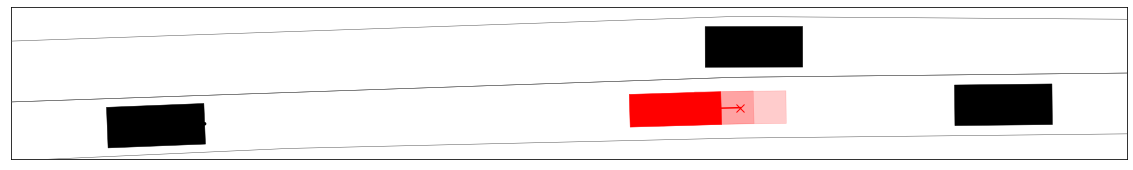

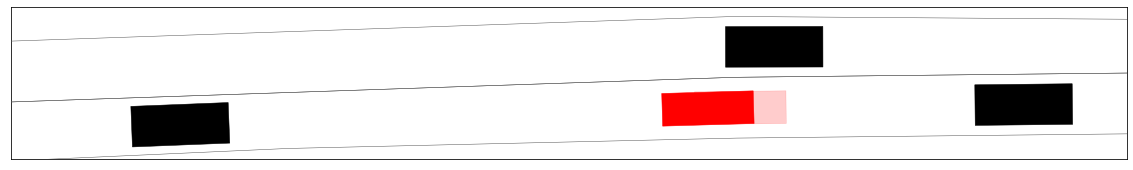

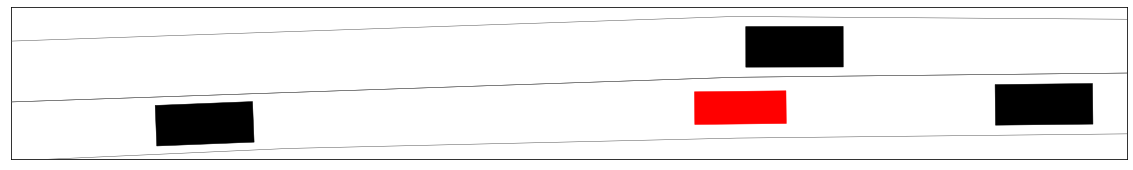

In [42]:
plot_limits = [-5, 50, -4.5, 3]
from commonroad_repair.crrepairer.repairer.visualization import visualize_initial_result
for time_step in range(ego_initial.prediction.final_time_step+1):
    visualize_initial_result(scenario,
                             ego_initial,
                             time_step,
                             plot_limits=plot_limits,
                             tv=repairer.tv)

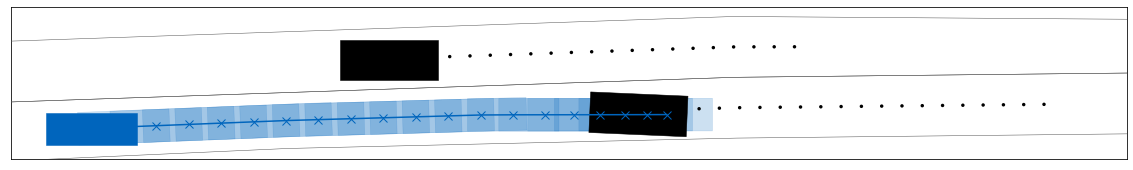

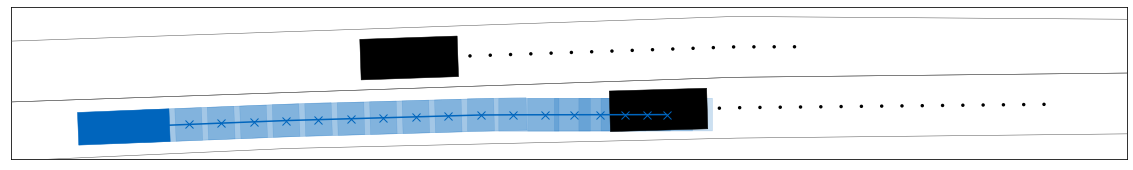

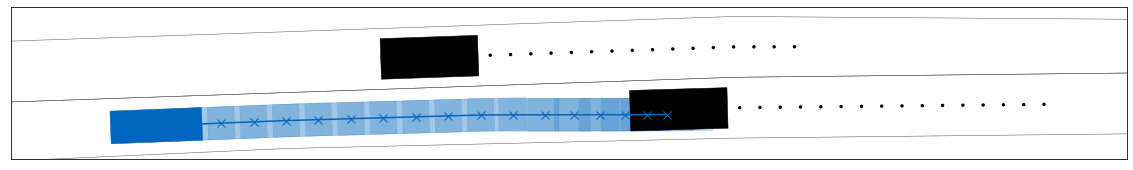

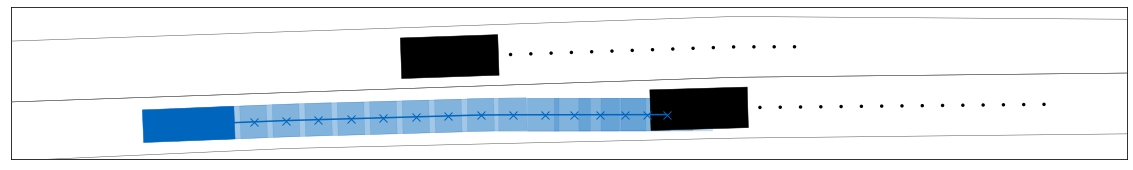

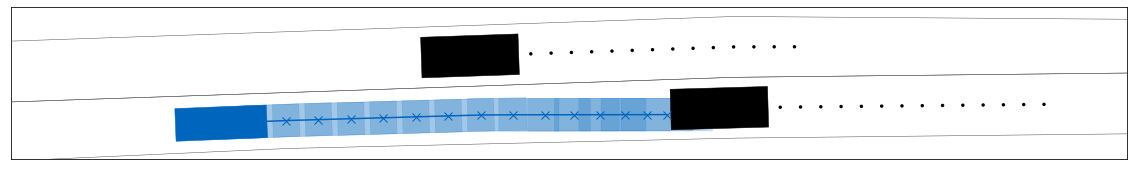

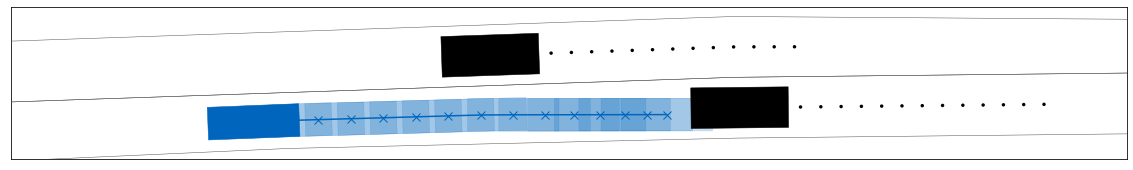

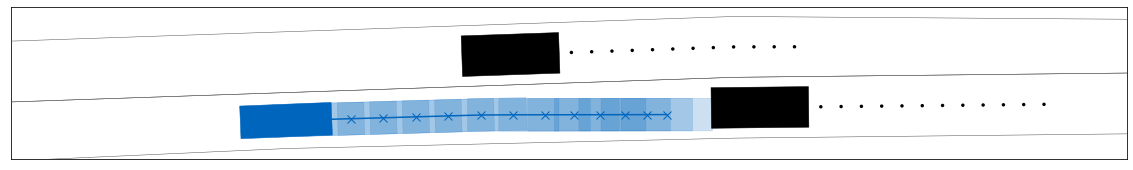

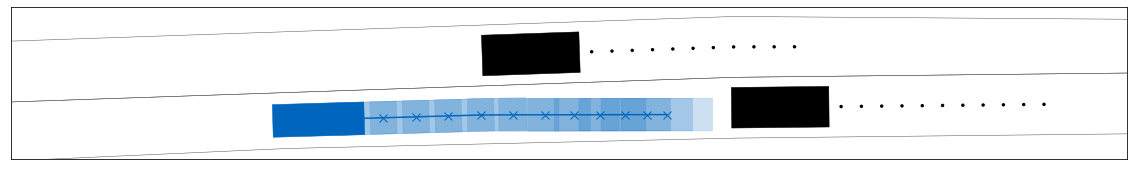

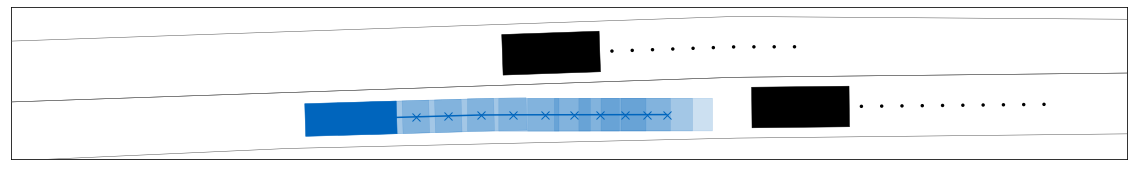

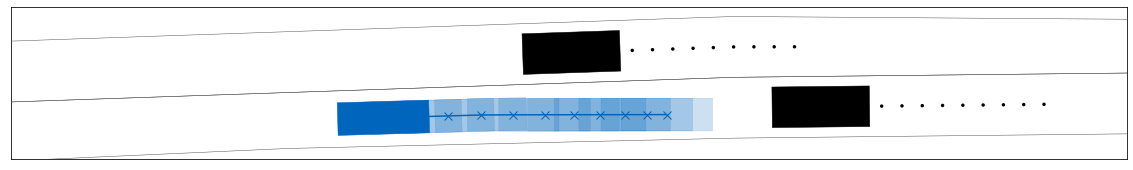

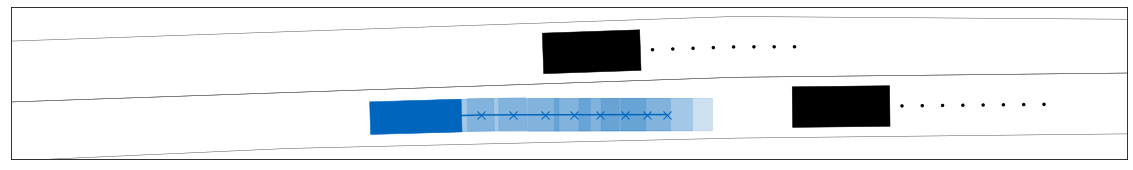

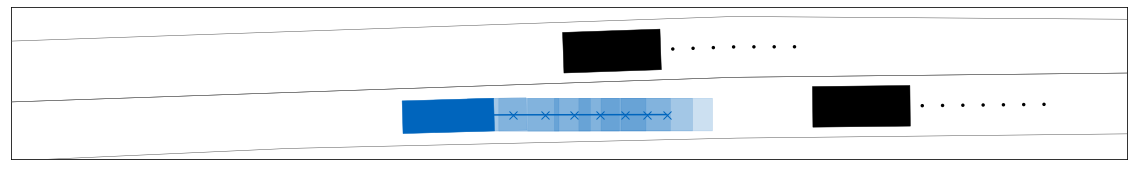

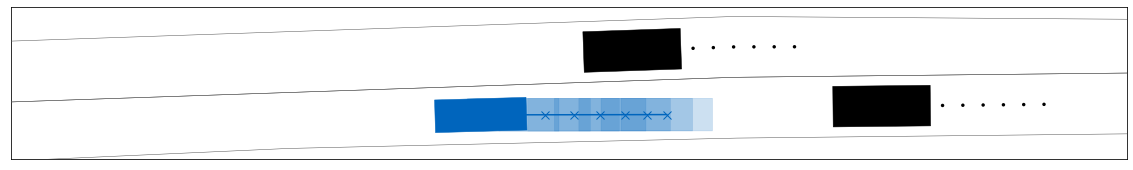

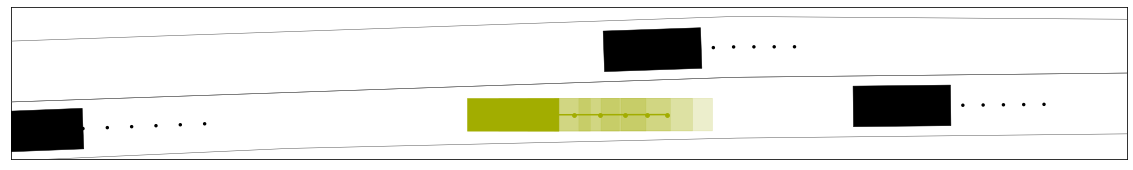

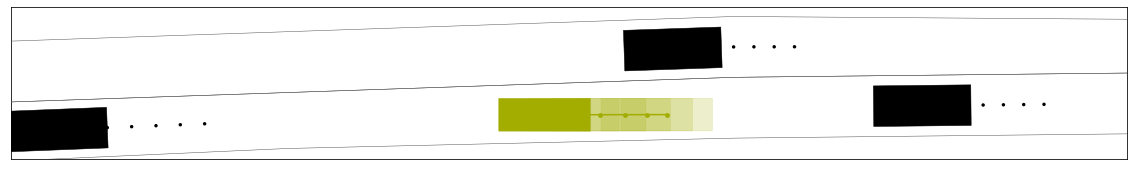

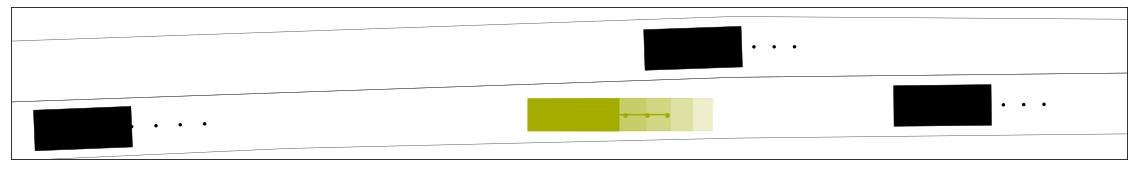

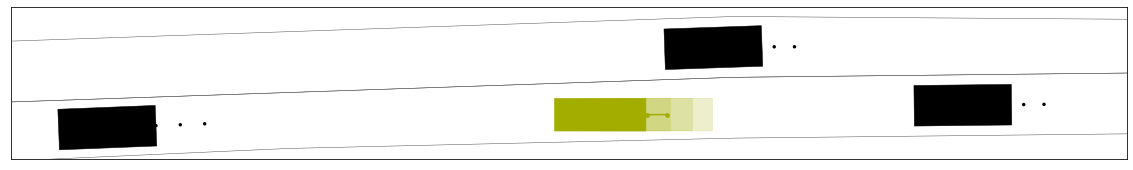

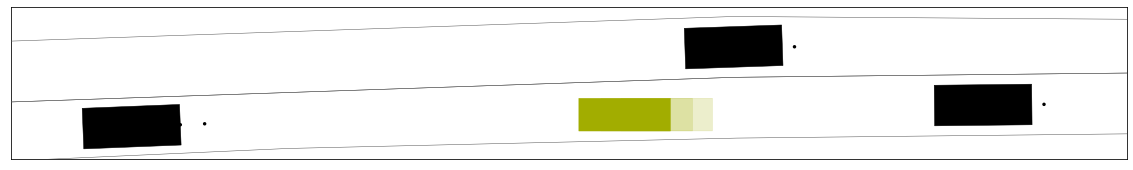

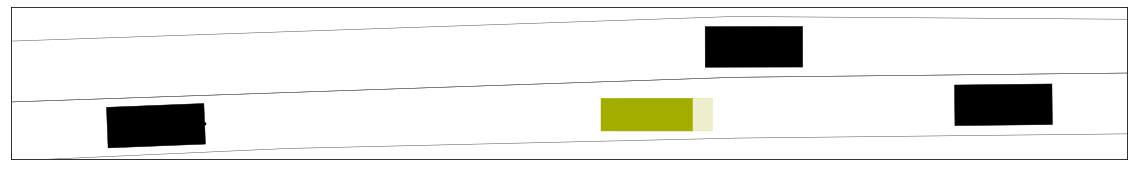

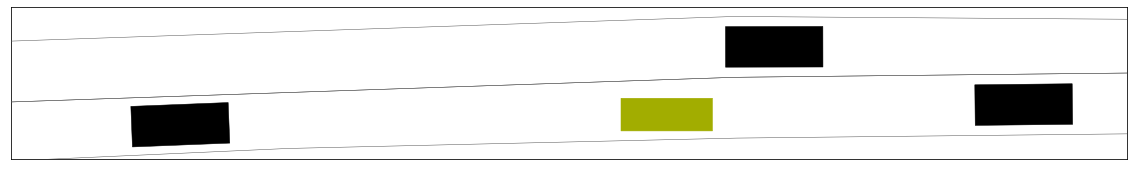

In [43]:
from commonroad_repair.crrepairer.repairer.visualization import visualize_repairing_result
for time_step in range(ego_vehicle.prediction.final_time_step+1):
    visualize_repairing_result(scenario,
                               ego_vehicle,
                               time_step,
                               plot_limits=plot_limits,
                               tc=repairer.tc)